In [433]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [434]:
df= pd.read_csv('../data/prepared.csv')
df.head()

,squaremeters,numberofrooms,hasyard,haspool,floors,citycode,citypartrange,numprevowners,made,isnewbuilt,hasstormprotector,basement,attic,garage,hasstorageroom,hasguestroom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


In [435]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squaremeters       10000 non-null  int64  
 1   numberofrooms      10000 non-null  int64  
 2   hasyard            10000 non-null  int64  
 3   haspool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   citycode           10000 non-null  int64  
 6   citypartrange      10000 non-null  int64  
 7   numprevowners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isnewbuilt         10000 non-null  int64  
 10  hasstormprotector  10000 non-null  int64  
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasstorageroom     10000 non-null  int64  
 15  hasguestroom       10000 non-null  int64  
 16  price              10000 non-null 

In [436]:
# Check the datatypes
(
    pd.DataFrame({
        'columns': df.columns,
        'Data Types': df.dtypes
    })
)

,columns,Data Types
squaremeters,squaremeters,int64
numberofrooms,numberofrooms,int64
hasyard,hasyard,int64
haspool,haspool,int64
floors,floors,int64
citycode,citycode,int64
citypartrange,citypartrange,int64
numprevowners,numprevowners,int64
made,made,int64
isnewbuilt,isnewbuilt,int64


In [437]:
df[['hasyard', 'haspool', 
    'isnewbuilt', 'hasstormprotector', 
    'hasstorageroom', 'hasguestroom', 'citypartrange', 'numprevowners']] = df[['hasyard', 'haspool', 
                                    'isnewbuilt', 'hasstormprotector', 
                                            'hasstorageroom','hasguestroom', 'citypartrange',
                                            'numprevowners']].astype('category')

In [438]:
# Check the datatypes
dtype_df = pd.DataFrame({
    'Data Types': df.dtypes.astype(str)
})

print(dtype_df)

                  Data Types
squaremeters           int64
numberofrooms          int64
hasyard             category
haspool             category
floors                 int64
citycode               int64
citypartrange       category
numprevowners       category
made                   int64
isnewbuilt          category
hasstormprotector   category
basement               int64
attic                  int64
garage                 int64
hasstorageroom      category
hasguestroom        category
price                float64


In [439]:
df.describe()

,squaremeters,numberofrooms,floors,citycode,made,basement,attic,garage,price
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.00000,1.000000e+04
mean,49870.13120,50.358400,50.276300,50225.486100,2005.48850,5033.103900,5028.01060,553.12120,4.993448e+06
std,28774.37535,28.816696,28.889171,29006.675799,9.30809,2876.729545,2894.33221,262.05017,2.877424e+06
min,89.00000,1.000000,1.000000,3.000000,1990.00000,0.000000,1.00000,100.00000,1.031350e+04
25%,25098.50000,25.000000,25.000000,24693.750000,1997.00000,2559.750000,2512.00000,327.75000,2.516402e+06
50%,50105.50000,50.000000,50.000000,50693.000000,2005.50000,5092.500000,5045.00000,554.00000,5.016180e+06
75%,74609.75000,75.000000,76.000000,75683.250000,2014.00000,7511.250000,7540.50000,777.25000,7.469092e+06
max,99999.00000,100.000000,100.000000,99953.000000,2021.00000,10000.000000,10000.00000,1000.00000,1.000677e+07


In [440]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['category']).columns

In [441]:
numerical_cols, categorical_cols

(Index(['squaremeters', 'numberofrooms', 'floors', 'citycode', 'made',
        'basement', 'attic', 'garage', 'price'],
       dtype='str'),
 Index(['hasyard', 'haspool', 'citypartrange', 'numprevowners', 'isnewbuilt',
        'hasstormprotector', 'hasstorageroom', 'hasguestroom'],
       dtype='str'))

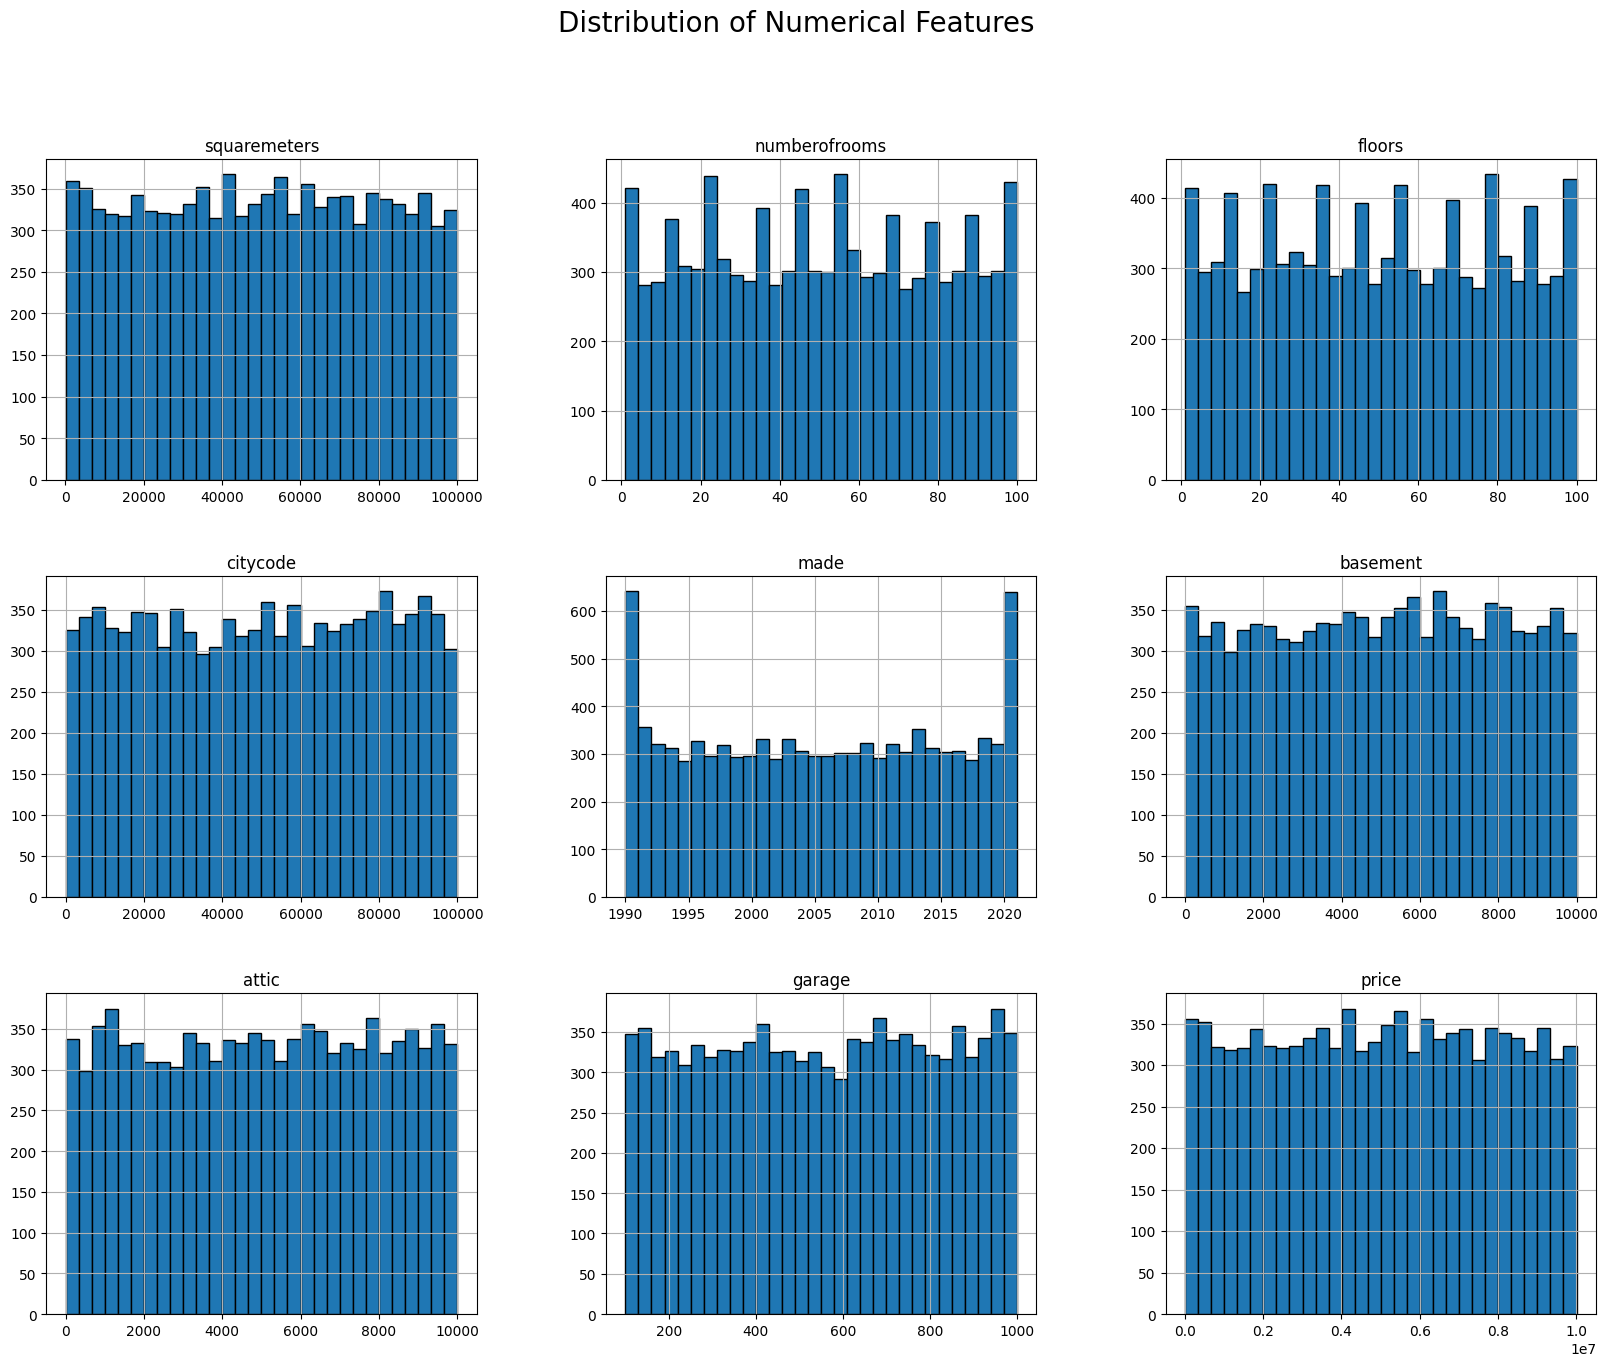

In [442]:
# Plot numerical features
df[numerical_cols].hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=20)
plt.show()

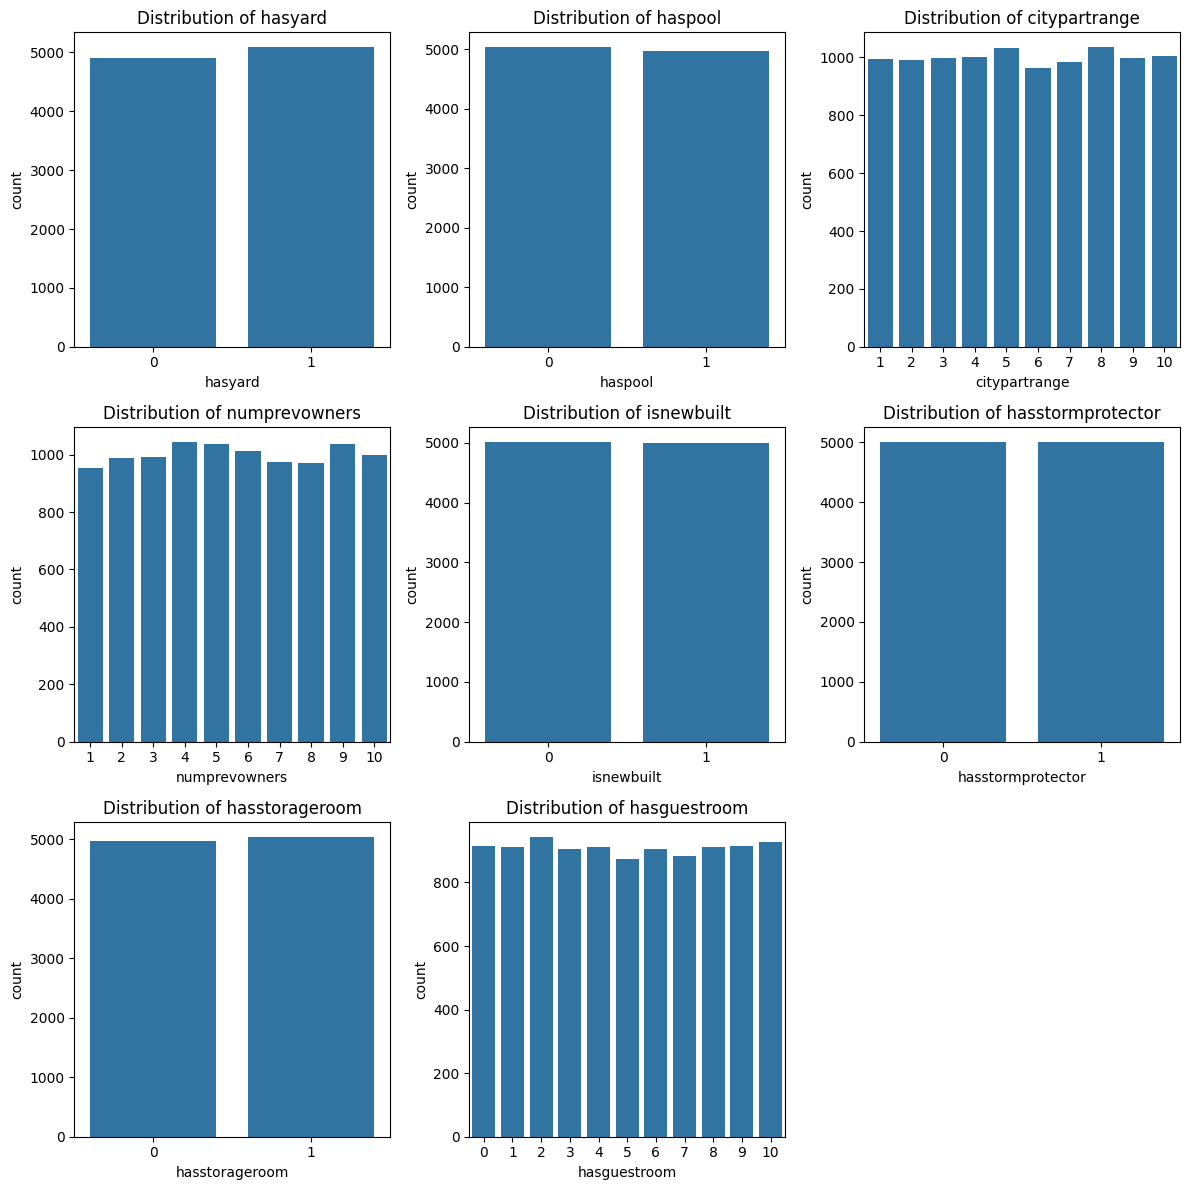

In [443]:
# Number of rows and columns for the grid
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Remove any empty subplots if categorical_cols < rows*cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [444]:
#df['price_log'] = np.log1p(df['price'])
#df['price_log']

### 'price' target feature

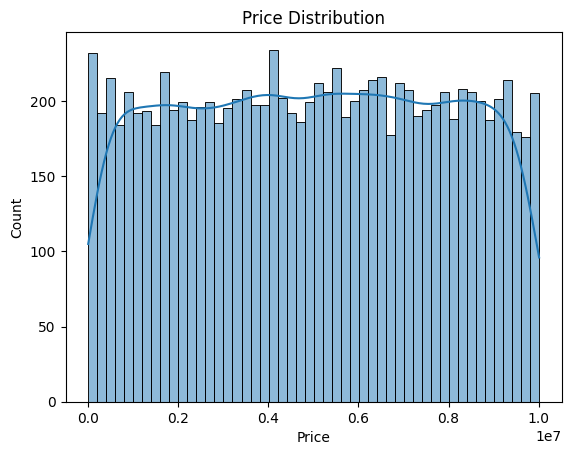

In [445]:
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

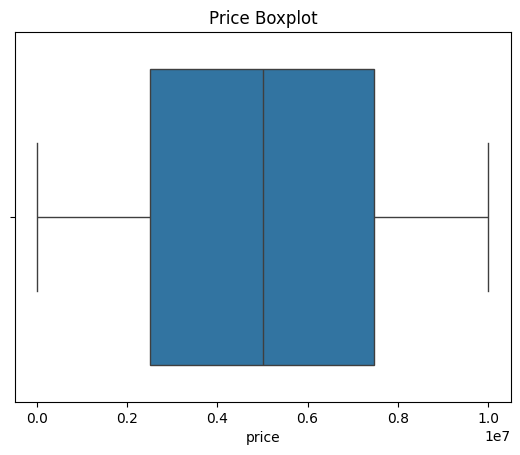

In [446]:
sns.boxplot(x=df['price'])
plt.title('Price Boxplot')
plt.show()

In [447]:
from scipy.stats import skew, kurtosis

print("Skewness:", skew(df['price']))
print("Kurtosis:", kurtosis(df['price']))

Skewness: -0.006448191698178405
Kurtosis: -1.1850410631048522


* Skewness ≈ 0 (-0.006) → The distribution is almost perfectly symmetric.
* Kurtosis < 0 (-1.185) → Slightly flatter than a normal distribution (light tails).
* Implication: The price target is well-behaved, with no extreme skew or heavy tails.
* Modeling impact: No transformation (e.g., log) is needed; standard regression models can be used directly.


### Exploratory Data Analysis

In [448]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price'],
      dtype='str')

In [449]:
# Mean price by haspool
pool_group = df.groupby('haspool')['price'].mean().reset_index()
pool_group

,haspool,price
0,0,5.007943e+06
1,1,4.978765e+06


In [450]:
# Mean price by numberofrooms
numberofrooms_group = df.groupby('numberofrooms')['price'].mean().sort_values(ascending=False)
numberofrooms_group

numberofrooms
55    5.828663e+06
45    5.528581e+06
60    5.497667e+06
77    5.473578e+06
89    5.467661e+06
          ...     
42    4.536043e+06
1     4.529113e+06
33    4.414912e+06
18    4.401772e+06
71    4.151713e+06
Name: price, Length: 100, dtype: float64

In [451]:
target = 'price'

In [452]:
# Function to compute mean price by categorical feature
def mean_price_by_category(df, target, categorical_cols):
    """
    Returns a dictionary of dataframes with mean target values for each categorical column.

    Parameters:
        df: pandas DataFrame
        target: str, name of the target column (e.g., 'price')
        categorical_cols: list of categorical column names
    """
    result = {}
    for col in categorical_cols:
        # Group by the categorical column
        grouped = df.groupby(col)[target].mean().reset_index()
        # Format the numbers to readable integers
        grouped[target] = grouped[target].apply(lambda x: f"{x:,.0f}")
        result[col] = grouped
    return result


In [453]:
mean_price_by_category(df, target, categorical_cols )

{'hasyard':   hasyard      price
 0       0  5,011,363
 1       1  4,976,144,
 'haspool':   haspool      price
 0       0  5,007,943
 1       1  4,978,765,
 'citypartrange':   citypartrange      price
 0             1  4,903,580
 1             2  4,931,873
 2             3  5,026,029
 3             4  4,932,945
 4             5  5,059,792
 5             6  4,990,101
 6             7  5,069,665
 7             8  5,082,120
 8             9  4,954,627
 9            10  4,978,567,
 'numprevowners':   numprevowners      price
 0             1  4,824,585
 1             2  5,007,744
 2             3  5,065,798
 3             4  4,927,437
 4             5  5,037,837
 5             6  4,862,583
 6             7  5,050,958
 7             8  4,944,788
 8             9  5,094,757
 9            10  5,109,954,
 'isnewbuilt':   isnewbuilt      price
 0          0  5,024,015
 1          1  4,962,770,
 'hasstormprotector':   hasstormprotector      price
 0                 0  4,971,884
 1               

# Key Insights from Groupby Analysis

### hasyard
- **No yard:** 5,011,363  
- **Has yard:** 4,976,144  
- Slightly higher price for houses without a yard (small difference).

### haspool
- **No pool:** 5,007,943  
- **Has pool:** 4,978,765  
- Small difference; pool presence doesn’t drastically change price.

### citypartrange
- Prices vary across city parts (**4,903,580 → 5,082,120**)  
- Some city parts (7 & 8) have the highest average prices.

### numprevowners
- Minor variations (**4,824,585 → 5,109,954**)  
- Number of previous owners doesn’t clearly correlate with price.

### isnewbuilt
- **New build (1):** 4,962,770  
- **Old build (0):** 5,024,015  
- Older houses have slightly higher mean price.

### hasstormprotector
- **No:** 4,971,884  
- **Yes:** 5,015,020  
- Storm protector slightly increases average price.

### hasstorageroom
- **No:** 5,003,536  
- **Yes:** 4,983,479  
- Small negative effect, almost negligible.

### hasguestroom
- Prices fluctuate between **4,807,832 → 5,129,961**  
- No clear linear trend; categorical treatment is appropriate.

In [454]:
import math

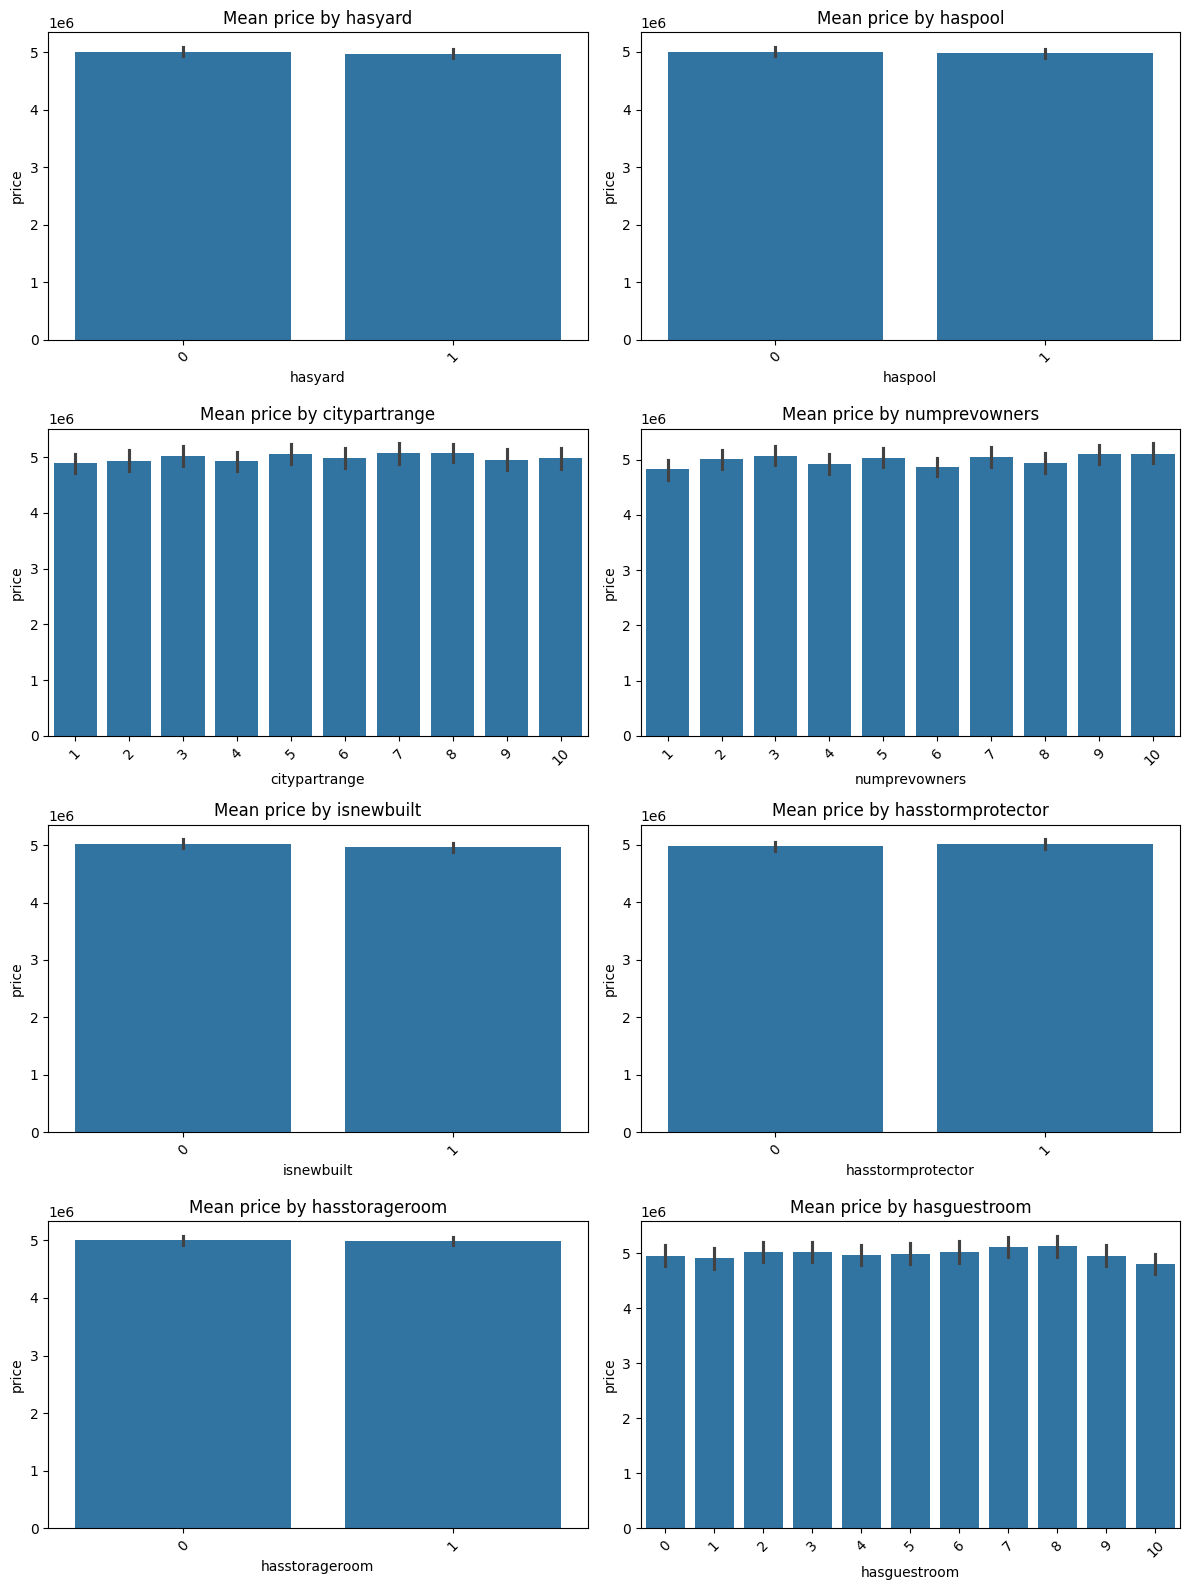

In [455]:
def plot_mean_price_by_category(df, target, categorical_cols):
    n_cols = 2  # number of columns in the grid
    n_rows = math.ceil(len(categorical_cols)/n_cols)  # calculate rows dynamically
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
    axes = axes.flatten()  # flatten in case of multiple rows
    
    for i, col in enumerate(categorical_cols):
        sns.barplot(x=col, y=target, data=df, ax=axes[i])
        axes[i].set_title(f'Mean {target} by {col}')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Now call it
plot_mean_price_by_category(df, target, categorical_cols)

In [456]:
for col in categorical_cols:
    summary = df.groupby(col)['price'].agg(['mean', 'median']).round(0)
    print(f"\n{col}")
    print(summary)


hasyard
              mean     median
hasyard                      
0        5011363.0  5014755.0
1        4976144.0  5016998.0

haspool
              mean     median
haspool                      
0        5007943.0  5027915.0
1        4978765.0  5006138.0

citypartrange
                    mean     median
citypartrange                      
1              4903580.0  4886434.0
2              4931873.0  4963035.0
3              5026029.0  5107816.0
4              4932945.0  4941102.0
5              5059792.0  5096676.0
6              4990101.0  4986838.0
7              5069665.0  5230357.0
8              5082120.0  5030382.0
9              4954627.0  4872303.0
10             4978567.0  5024096.0

numprevowners
                    mean     median
numprevowners                      
1              4824585.0  4791242.0
2              5007744.0  5030780.0
3              5065798.0  5076210.0
4              4927437.0  4782452.0
5              5037837.0  4977036.0
6              4862583.0  49

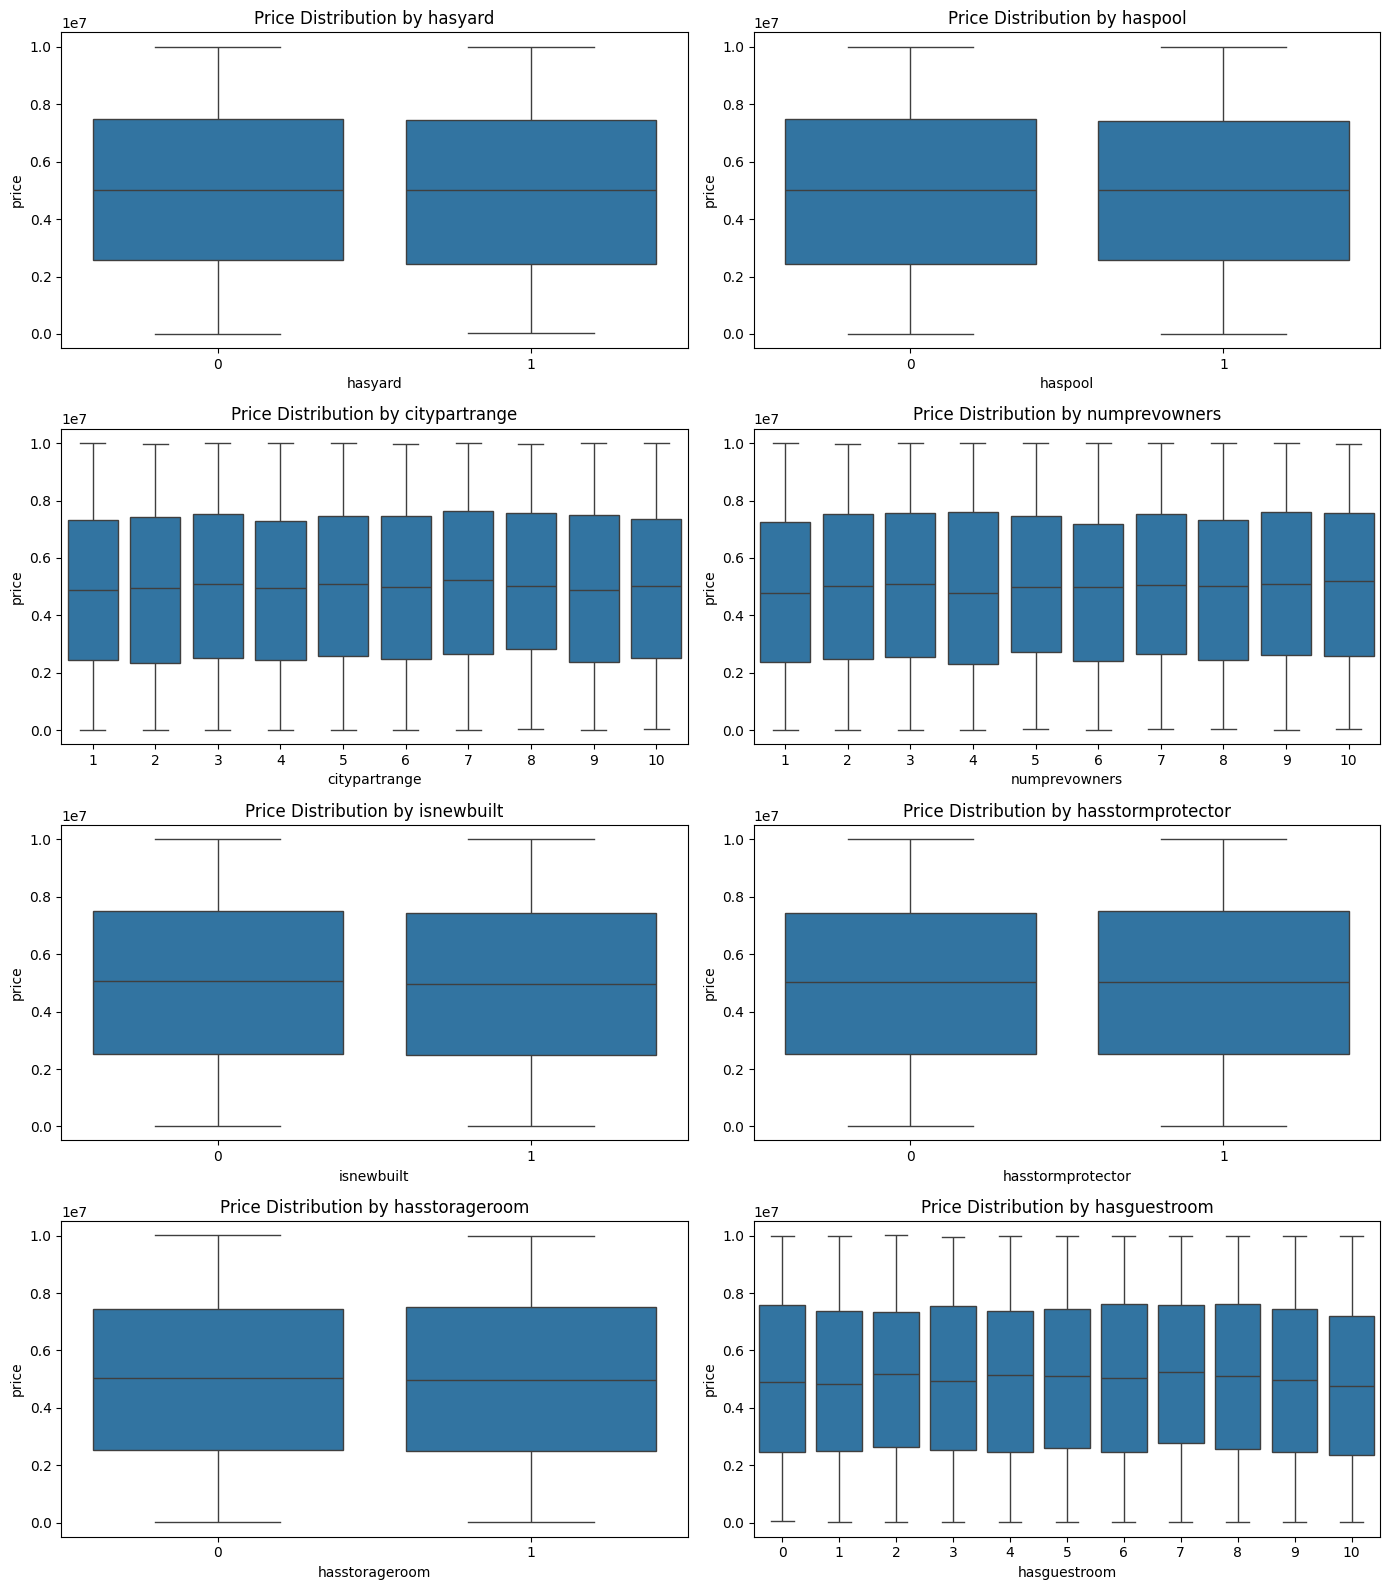

In [457]:
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'Price Distribution by {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Numerical Features vs price

In [458]:
# Correlation with price
corr_matrix = df[numerical_cols].corr()
corr_matrix

,squaremeters,numberofrooms,floors,citycode,made,basement,attic,garage,price
squaremeters,1.000000,0.009573,0.001109,-0.001541,-0.007207,-0.003960,-0.000588,-0.017246,0.999999
numberofrooms,0.009573,1.000000,0.022244,0.009040,0.003978,-0.013990,0.012061,0.023188,0.009591
floors,0.001109,0.022244,1.000000,0.002207,0.005022,0.006228,-0.000270,0.011303,0.001654
citycode,-0.001541,0.009040,0.002207,1.000000,0.009266,0.002652,-0.002019,-0.002208,-0.001539
made,-0.007207,0.003978,0.005022,0.009266,1.000000,-0.005506,0.013773,0.005687,-0.007210
basement,-0.003960,-0.013990,0.006228,0.002652,-0.005506,1.000000,-0.003180,0.000117,-0.003967
attic,-0.000588,0.012061,-0.000270,-0.002019,0.013773,-0.003180,1.000000,-0.000611,-0.000600
garage,-0.017246,0.023188,0.011303,-0.002208,0.005687,0.000117,-0.000611,1.000000,-0.017229
price,0.999999,0.009591,0.001654,-0.001539,-0.007210,-0.003967,-0.000600,-0.017229,1.000000


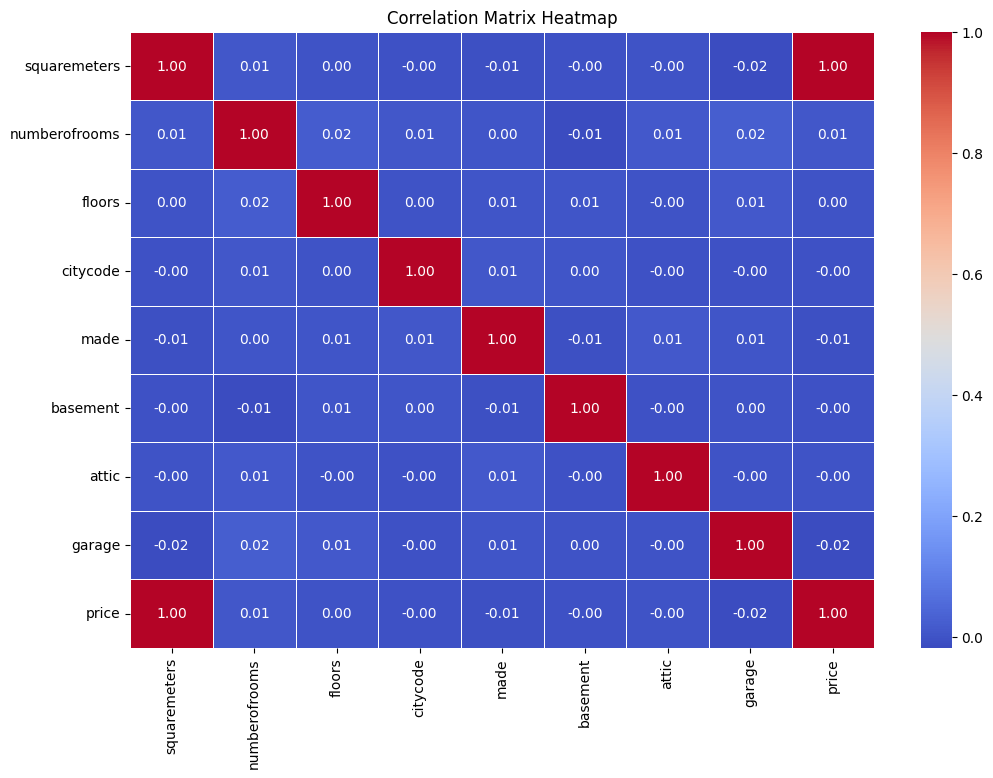

In [459]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Matrix Heatmap')
plt.show()

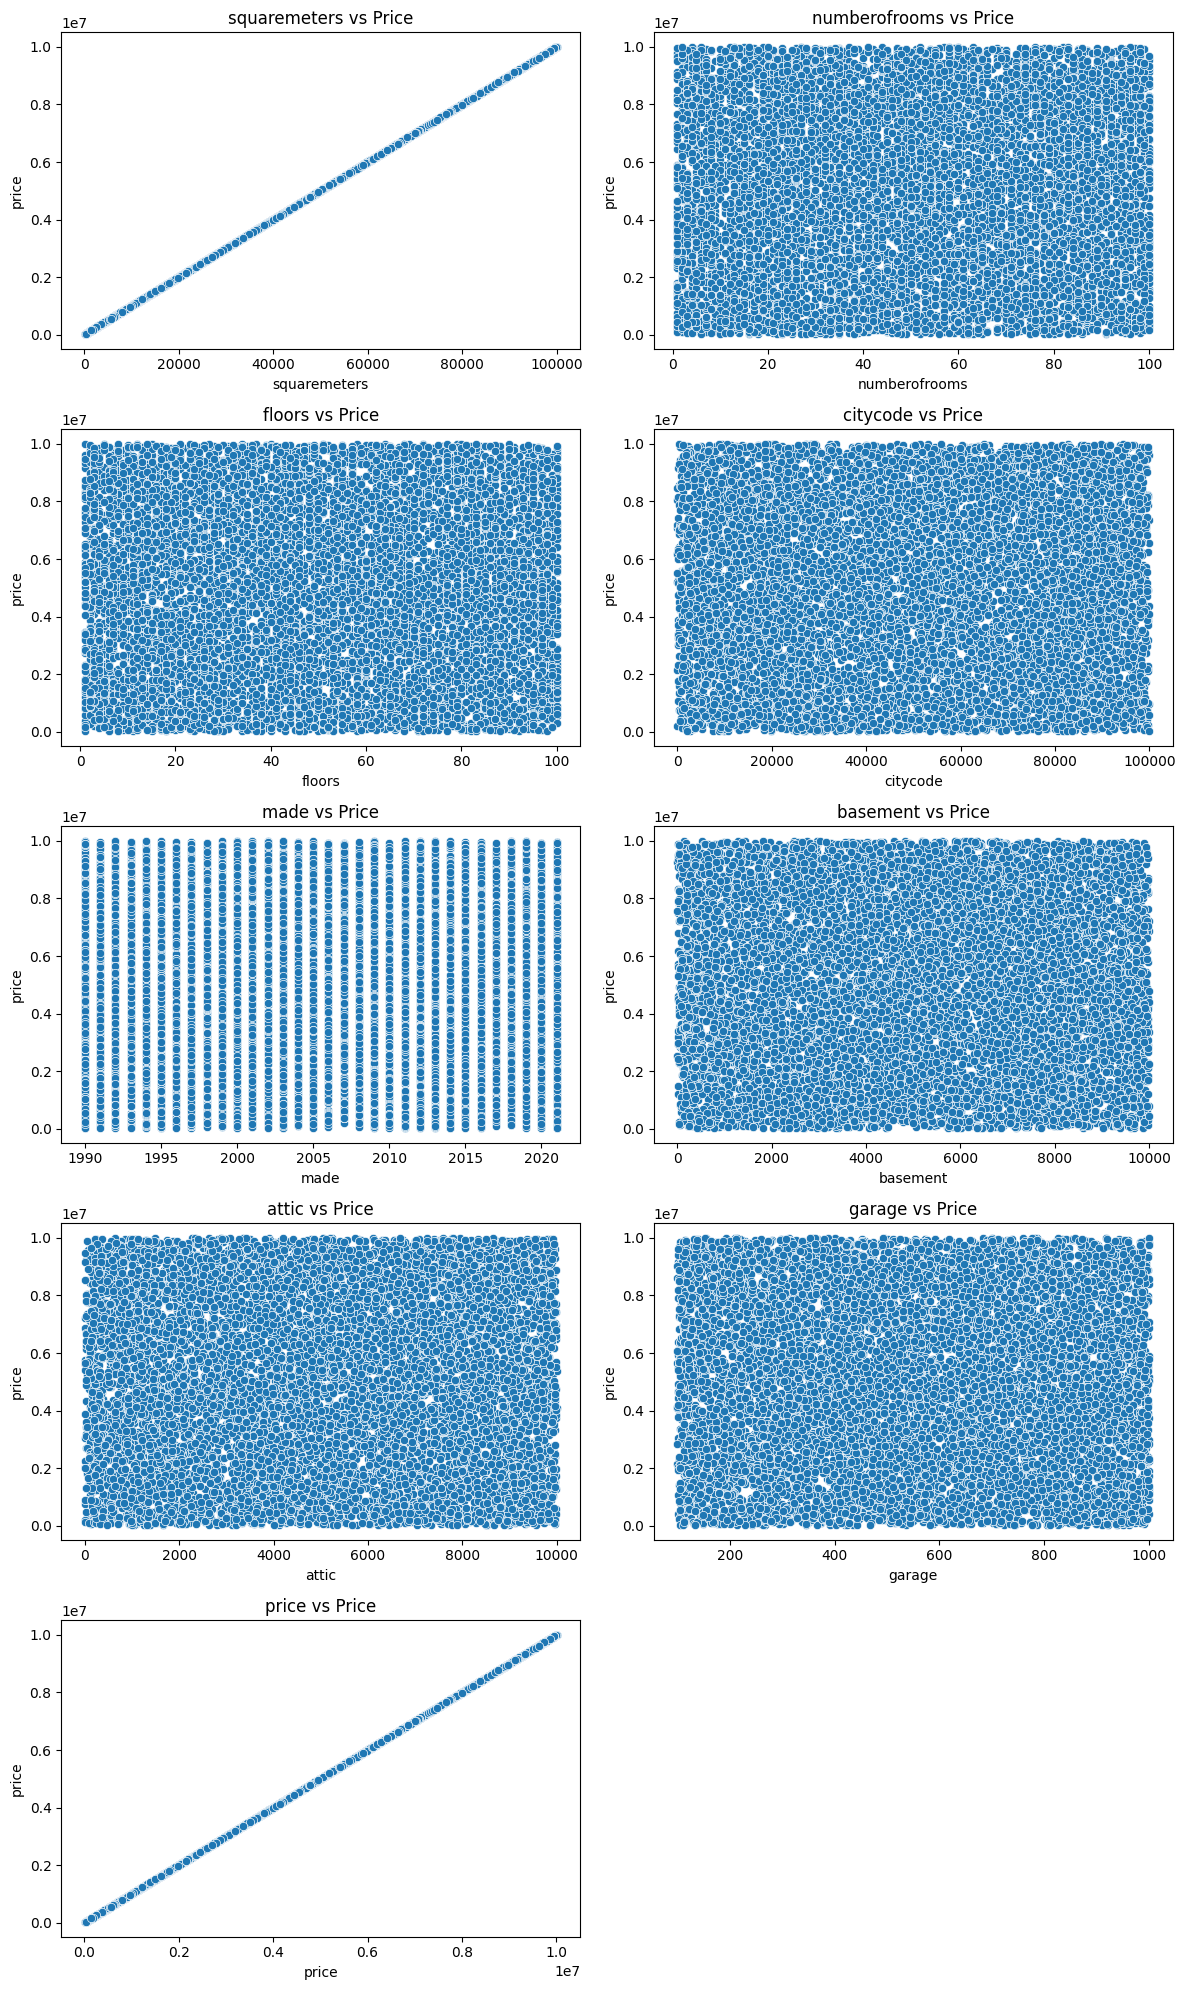

In [460]:

# Set up grid for plots
n_cols = 2
n_rows = math.ceil(len(numerical_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
axes = axes.flatten()

# Create scatterplots
for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    
# Remove any unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [461]:
# Convert categorical to integer temporarily
df['hasyard_num'] = df['hasyard'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_hasyard'] = df['squaremeters'] * df['hasyard_num']

# Quick check
df[['squaremeters', 'hasyard', 'squaremeters_hasyard']].head()

,squaremeters,hasyard,squaremeters_hasyard
0,75523,0,0
1,80771,1,80771
2,55712,0,0
3,32316,0,0
4,70429,1,70429


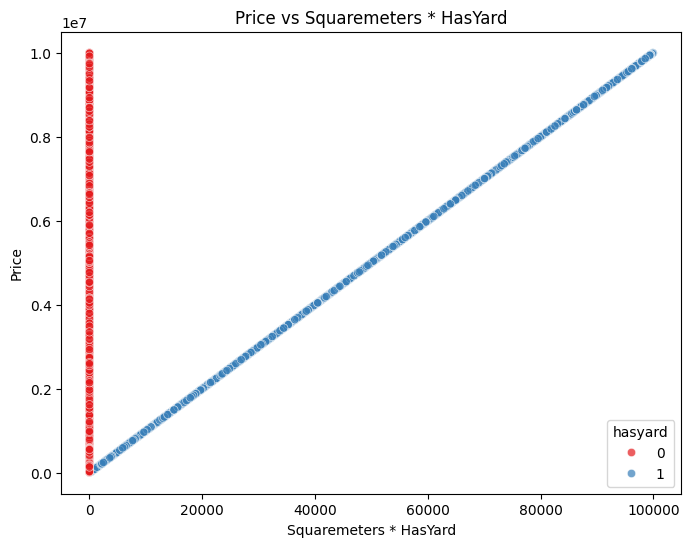

In [462]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_hasyard',
    y='price',
    hue='hasyard',  # show yard presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * HasYard')
plt.xlabel('Squaremeters * HasYard')
plt.ylabel('Price')
plt.show()

In [463]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price', 'hasyard_num', 'squaremeters_hasyard'],
      dtype='str')

In [464]:
# Convert categorical to integer temporarily
#df['numberofrooms_num'] = df['numberofrooms'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_numberofrooms'] = df['squaremeters'] * df['numberofrooms']

# Quick check
df[['squaremeters', 'numberofrooms', 'squaremeters_numberofrooms']].head()

,squaremeters,numberofrooms,squaremeters_numberofrooms
0,75523,3,226569
1,80771,39,3150069
2,55712,58,3231296
3,32316,47,1518852
4,70429,19,1338151


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/1698784653.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


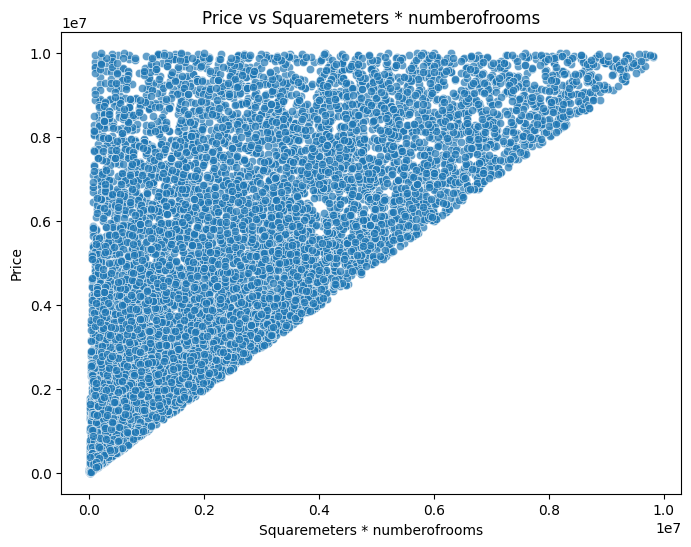

In [465]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_numberofrooms',
    y='price',
    #hue='numberofrooms',  # show yard presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * numberofrooms')
plt.xlabel('Squaremeters * numberofrooms')
plt.ylabel('Price')
plt.show()

In [466]:
df

,squaremeters,numberofrooms,hasyard,haspool,floors,citycode,citypartrange,numprevowners,made,isnewbuilt,hasstormprotector,basement,attic,garage,hasstorageroom,hasguestroom,price,hasyard_num,squaremeters_hasyard,squaremeters_numberofrooms
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5,0,0,226569
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5,1,80771,3150069
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1,0,0,3231296
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2,0,0,1518852
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0,1,70429,1338151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1726,89,0,1,5,73133,7,6,2009,0,1,9311,1698,218,0,4,176425.9,0,0,153614
9996,44403,29,1,1,12,34606,9,4,1990,0,1,9061,1742,230,0,0,4448474.0,1,44403,1287687
9997,83841,3,0,0,69,80933,10,10,2005,1,1,8304,7730,345,1,9,8390030.5,0,0,251523
9998,59036,70,0,0,96,55856,1,3,2010,0,1,2590,6174,339,1,4,5905107.0,0,0,4132520


In [467]:
# Convert categorical to integer temporarily
df['haspool_num'] = df['haspool'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_haspool'] = df['squaremeters'] * df['haspool_num']

# Quick check
df[['squaremeters', 'haspool', 'squaremeters_haspool']].head()

,squaremeters,haspool,squaremeters_haspool
0,75523,1,75523
1,80771,1,80771
2,55712,1,55712
3,32316,0,0
4,70429,1,70429


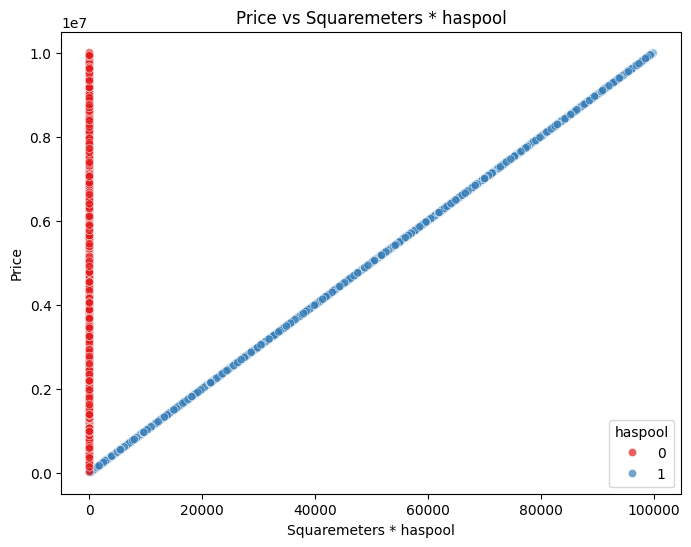

In [468]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_haspool',
    y='price',
    hue='haspool',  # show yard presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * haspool')
plt.xlabel('Squaremeters * haspool')
plt.ylabel('Price')
plt.show()

In [469]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price', 'hasyard_num', 'squaremeters_hasyard',
       'squaremeters_numberofrooms', 'haspool_num', 'squaremeters_haspool'],
      dtype='str')

In [470]:
# Convert categorical to integer temporarily
#df['citycode_num'] = df['citycode'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_citycode'] = df['squaremeters'] * df['citycode']

# Quick check
df[['squaremeters', 'citycode', 'squaremeters_citycode']].head()

,squaremeters,citycode,squaremeters_citycode
0,75523,9373,707877079
1,80771,39381,3180842751
2,55712,34457,1919668384
3,32316,27939,902876724
4,70429,38045,2679471305


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/4212625202.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


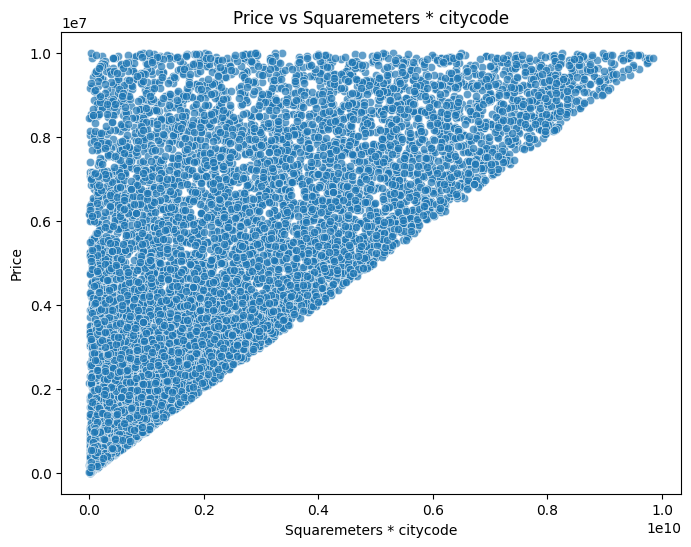

In [471]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_citycode',
    y='price',
    #hue='citycode',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * citycode')
plt.xlabel('Squaremeters * citycode')
plt.ylabel('Price')
plt.show()

In [472]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price', 'hasyard_num', 'squaremeters_hasyard',
       'squaremeters_numberofrooms', 'haspool_num', 'squaremeters_haspool',
       'squaremeters_citycode'],
      dtype='str')

In [473]:
# Convert categorical to integer temporarily
df['citypartrange_num'] = df['citypartrange'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_citypartrange'] = df['squaremeters'] * df['citypartrange_num']

# Quick check
df[['squaremeters', 'citypartrange', 'squaremeters_citypartrange']].head()

,squaremeters,citypartrange,squaremeters_citypartrange
0,75523,3,151046
1,80771,8,565397
2,55712,6,278560
3,32316,10,290844
4,70429,3,140858


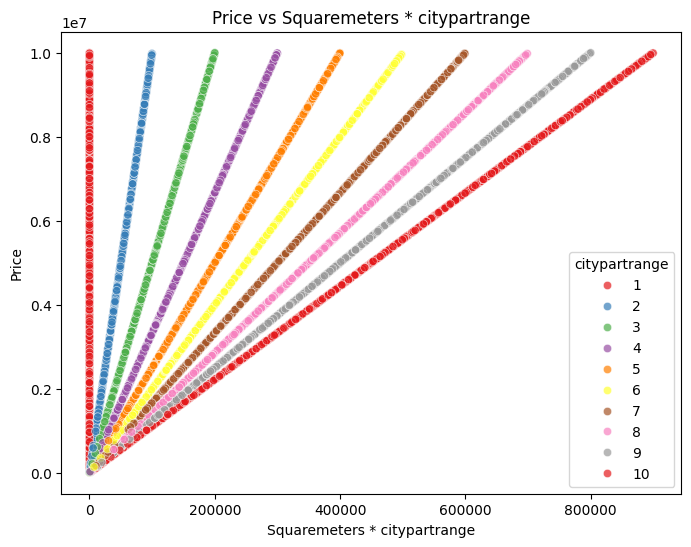

In [474]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_citypartrange',
    y='price',
    hue='citypartrange',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * citypartrange')
plt.xlabel('Squaremeters * citypartrange')
plt.ylabel('Price')
plt.show()

In [475]:
# Convert categorical to integer temporarily
df['numprevowners_num'] = df['numprevowners'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_numprevowners'] = df['squaremeters'] * df['numprevowners_num']

# Quick check
df[['squaremeters', 'numprevowners', 'squaremeters_numprevowners']].head()

,squaremeters,numprevowners,squaremeters_numprevowners
0,75523,8,528661
1,80771,6,403855
2,55712,8,389984
3,32316,4,96948
4,70429,7,422574


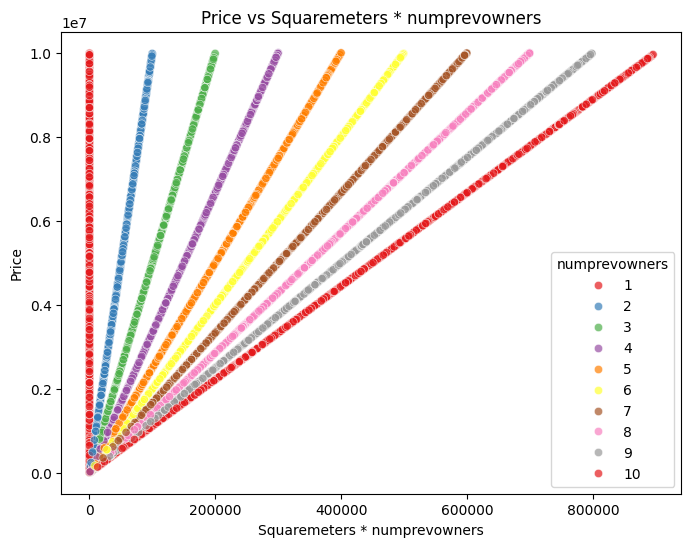

In [476]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_numprevowners',
    y='price',
    hue='numprevowners',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * numprevowners')
plt.xlabel('Squaremeters * numprevowners')
plt.ylabel('Price')
plt.show()

In [477]:
# Convert categorical to integer temporarily
#df['made_num'] = df['made'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_made'] = df['squaremeters'] * df['made']

# Quick check
df[['squaremeters', 'made', 'squaremeters_made']].head()

,squaremeters,made,squaremeters_made
0,75523,2005,151423615
1,80771,2015,162753565
2,55712,2021,112593952
3,32316,2012,65019792
4,70429,1990,140153710


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/4232024412.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


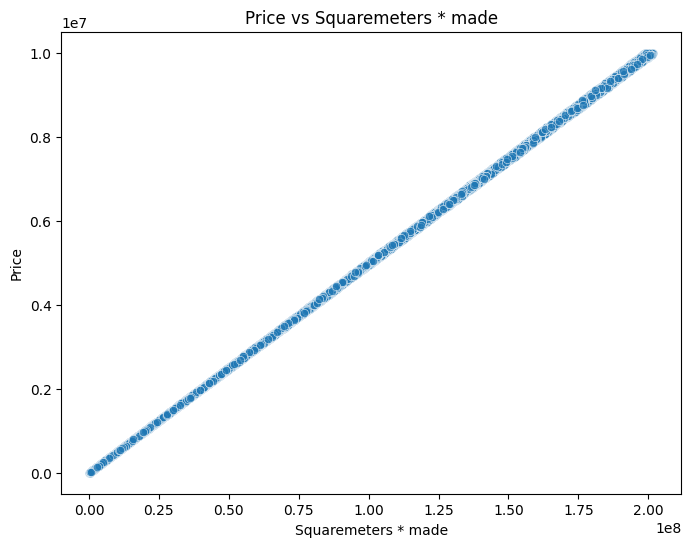

In [478]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_made',
    y='price',
    #hue='made',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * made')
plt.xlabel('Squaremeters * made')
plt.ylabel('Price')
plt.show()

In [479]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price', 'hasyard_num', 'squaremeters_hasyard',
       'squaremeters_numberofrooms', 'haspool_num', 'squaremeters_haspool',
       'squaremeters_citycode', 'citypartrange_num',
       'squaremeters_citypartrange', 'numprevowners_num',
       'squaremeters_numprevowners', 'squaremeters_made'],
      dtype='str')

In [480]:
# Convert categorical to integer temporarily
df['isnewbuilt_num'] = df['isnewbuilt'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_isnewbuilt'] = df['squaremeters'] * df['isnewbuilt_num']

# Quick check
df[['squaremeters', 'isnewbuilt', 'squaremeters_isnewbuilt']].head()

,squaremeters,isnewbuilt,squaremeters_isnewbuilt
0,75523,0,0
1,80771,1,80771
2,55712,0,0
3,32316,0,0
4,70429,1,70429


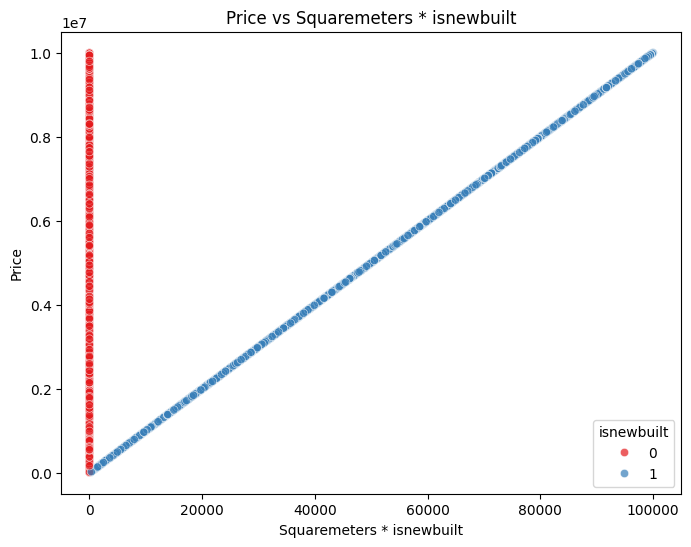

In [481]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_isnewbuilt',
    y='price',
    hue='isnewbuilt',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * isnewbuilt')
plt.xlabel('Squaremeters * isnewbuilt')
plt.ylabel('Price')
plt.show()

In [482]:
# Convert categorical to integer temporarily
df['hasstormprotector_num'] = df['hasstormprotector'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_hasstormprotector'] = df['squaremeters'] * df['hasstormprotector_num']

# Quick check
df[['squaremeters', 'hasstormprotector', 'squaremeters_hasstormprotector']].head()

,squaremeters,hasstormprotector,squaremeters_hasstormprotector
0,75523,1,75523
1,80771,0,0
2,55712,0,0
3,32316,1,32316
4,70429,0,0


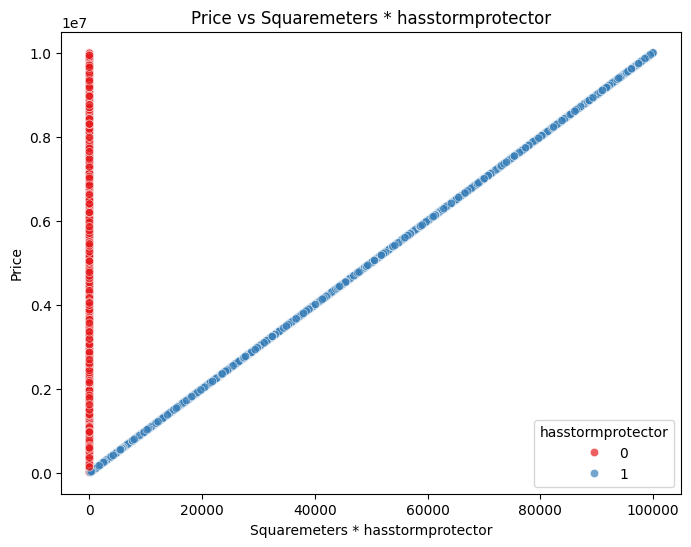

In [483]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_hasstormprotector',
    y='price',
    hue='hasstormprotector',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * hasstormprotector')
plt.xlabel('Squaremeters * hasstormprotector')
plt.ylabel('Price')
plt.show()

In [484]:
# Convert categorical to integer temporarily
#df['basement_num'] = df['basement'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_basement'] = df['squaremeters'] * df['basement']

# Quick check
df[['squaremeters', 'basement', 'squaremeters_basement']].head()

,squaremeters,basement,squaremeters_basement
0,75523,4313,325730699
1,80771,3653,295056463
2,55712,2937,163626144
3,32316,659,21296244
4,70429,8435,594068615


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/106354827.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


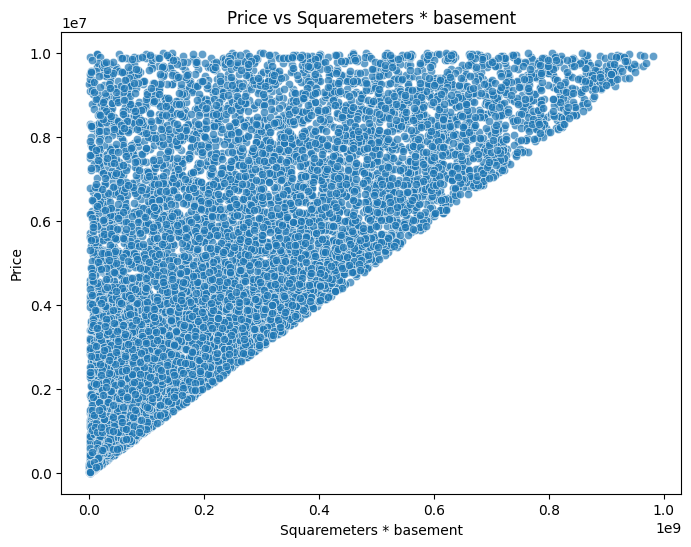

In [485]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_basement',
    y='price',
    #hue='basement',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * basement')
plt.xlabel('Squaremeters * basement')
plt.ylabel('Price')
plt.show()

In [486]:
df.columns

Index(['squaremeters', 'numberofrooms', 'hasyard', 'haspool', 'floors',
       'citycode', 'citypartrange', 'numprevowners', 'made', 'isnewbuilt',
       'hasstormprotector', 'basement', 'attic', 'garage', 'hasstorageroom',
       'hasguestroom', 'price', 'hasyard_num', 'squaremeters_hasyard',
       'squaremeters_numberofrooms', 'haspool_num', 'squaremeters_haspool',
       'squaremeters_citycode', 'citypartrange_num',
       'squaremeters_citypartrange', 'numprevowners_num',
       'squaremeters_numprevowners', 'squaremeters_made', 'isnewbuilt_num',
       'squaremeters_isnewbuilt', 'hasstormprotector_num',
       'squaremeters_hasstormprotector', 'squaremeters_basement'],
      dtype='str')

In [487]:
# Convert categorical to integer temporarily
#df['attic_num'] = df['attic'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_attic'] = df['squaremeters'] * df['attic']

# Quick check
df[['squaremeters', 'attic', 'squaremeters_attic']].head()

,squaremeters,attic,squaremeters_attic
0,75523,9005,680084615
1,80771,2436,196758156
2,55712,8852,493162624
3,32316,7141,230768556
4,70429,2429,171072041


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/4048915577.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


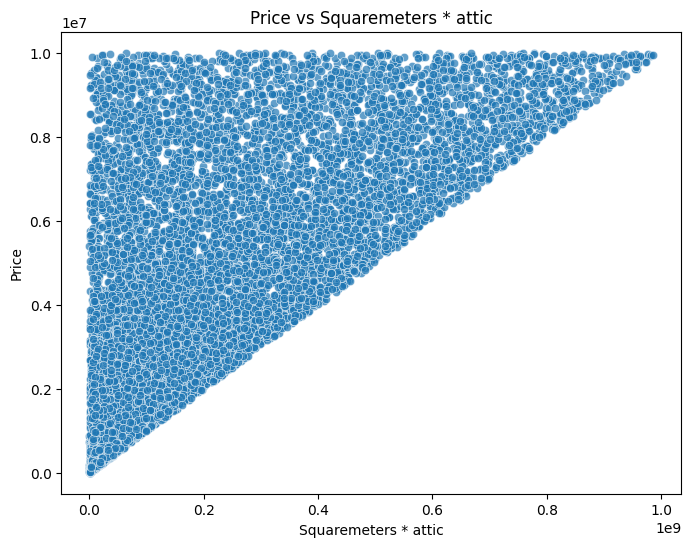

In [488]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_attic',
    y='price',
    #hue='attic',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * attic')
plt.xlabel('Squaremeters * attic')
plt.ylabel('Price')
plt.show()

In [489]:
# Convert categorical to integer temporarily
#df['garage_num'] = df['garage'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_garage'] = df['squaremeters'] * df['garage']

# Quick check
df[['squaremeters', 'garage', 'squaremeters_garage']].head()

,squaremeters,garage,squaremeters_garage
0,75523,956,72199988
1,80771,128,10338688
2,55712,135,7521120
3,32316,359,11601444
4,70429,292,20565268


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/2913477307.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


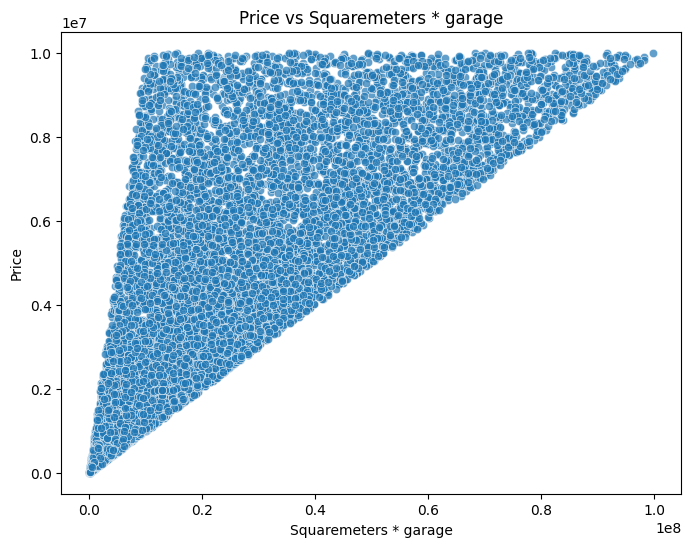

In [490]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_garage',
    y='price',
    #hue='garage',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * garage')
plt.xlabel('Squaremeters * garage')
plt.ylabel('Price')
plt.show()

In [491]:
# Convert categorical to integer temporarily
df['hasstorageroom_num'] = df['hasstorageroom'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_hasstorageroom'] = df['squaremeters'] * df['hasstorageroom_num']

# Quick check
df[['squaremeters', 'hasstorageroom', 'squaremeters_hasstorageroom']].head()

,squaremeters,hasstorageroom,squaremeters_hasstorageroom
0,75523,0,0
1,80771,1,80771
2,55712,1,55712
3,32316,0,0
4,70429,1,70429


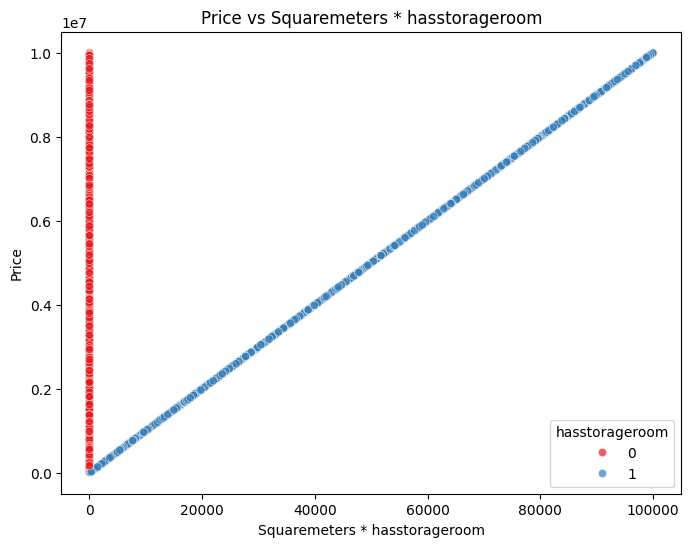

In [492]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_hasstorageroom',
    y='price',
    hue='hasstorageroom',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * hasstorageroom')
plt.xlabel('Squaremeters * hasstorageroom')
plt.ylabel('Price')
plt.show()

In [493]:
# Convert categorical to integer temporarily
df['hasguestroom_num'] = df['hasguestroom'].cat.codes  # 0/1 encoding

# Create interaction feature
df['squaremeters_hasguestroom'] = df['squaremeters'] * df['hasguestroom_num']

# Quick check
df[['squaremeters', 'hasguestroom', 'squaremeters_hasguestroom']].head()

,squaremeters,hasguestroom,squaremeters_hasguestroom
0,75523,7,528661
1,80771,2,161542
2,55712,9,501408
3,32316,3,96948
4,70429,4,281716


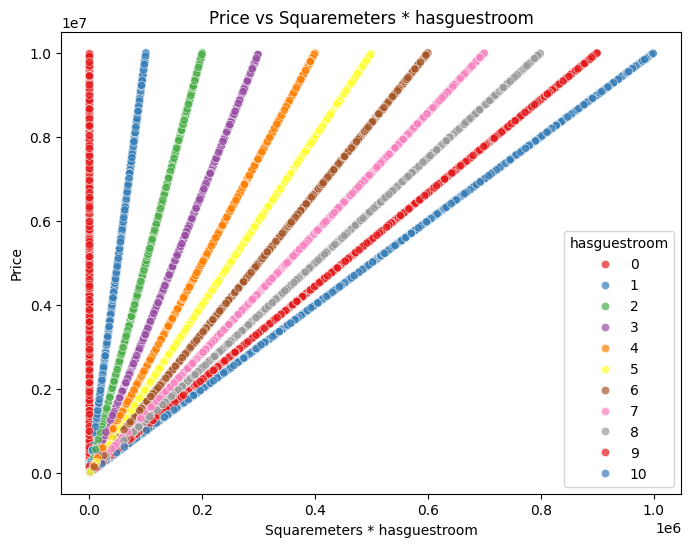

In [494]:
# Scatterplot for squaremeters_hasyard vs price
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='squaremeters_hasguestroom',
    y='price',
    hue='hasguestroom',  # show citycode presence
    palette='Set1',
    alpha=0.7
)
plt.title('Price vs Squaremeters * hasguestroom')
plt.xlabel('Squaremeters * hasguestroom')
plt.ylabel('Price')
plt.show()

#### Polynomial Features

In [495]:
df['squaremeters_squared'] = df['squaremeters'] ** 2
df['numberofrooms_squared'] = df['numberofrooms'] ** 2

In [496]:
# Square meters buckets
df['squaremeters_bin'] = pd.qcut(df['squaremeters'], 4, labels=['small', 'medium', 'large', 'xlarge'])

# Number of previous owners
df['numprevowners_bin'] = pd.cut(df['numprevowners'], bins=[0,2,5,10], labels=['few','moderate','many'])

In [497]:
# Average price per city part
df['avg_price_citypart'] = df.groupby('citypartrange')['price'].transform('mean')

# Average size per number of rooms
df['avg_size_rooms'] = df.groupby('numberofrooms')['squaremeters'].transform('mean')

In [498]:
# Price per square meter
df['price_per_sqm'] = df['price'] / df['squaremeters']

# Rooms per floor
df['rooms_per_floor'] = df['numberofrooms'] / df['floors']

In [499]:
new_numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
new_numerical_cols

['squaremeters',
 'numberofrooms',
 'floors',
 'citycode',
 'made',
 'basement',
 'attic',
 'garage',
 'price',
 'squaremeters_hasyard',
 'squaremeters_numberofrooms',
 'squaremeters_haspool',
 'squaremeters_citycode',
 'squaremeters_citypartrange',
 'squaremeters_numprevowners',
 'squaremeters_made',
 'squaremeters_isnewbuilt',
 'squaremeters_hasstormprotector',
 'squaremeters_basement',
 'squaremeters_attic',
 'squaremeters_garage',
 'squaremeters_hasstorageroom',
 'squaremeters_hasguestroom',
 'squaremeters_squared',
 'numberofrooms_squared',
 'avg_price_citypart',
 'avg_size_rooms',
 'price_per_sqm',
 'rooms_per_floor']

In [500]:
df_corr = df[new_numerical_cols].corr()
df_corr

,squaremeters,numberofrooms,floors,citycode,made,basement,attic,garage,price,squaremeters_hasyard,...,squaremeters_attic,squaremeters_garage,squaremeters_hasstorageroom,squaremeters_hasguestroom,squaremeters_squared,numberofrooms_squared,avg_price_citypart,avg_size_rooms,price_per_sqm,rooms_per_floor
squaremeters,1.000000,0.009573,0.001109,-0.001541,-0.007207,-0.003960,-0.000588,-0.017246,0.999999,0.454585,...,0.655738,0.721232,0.451416,0.621628,0.967611,0.002936,0.021007,0.100075,-0.280279,-0.008555
numberofrooms,0.009573,1.000000,0.022244,0.009040,0.003978,-0.013990,0.012061,0.023188,0.009591,-0.000862,...,0.014943,0.024277,0.003465,-0.010922,0.007969,0.968495,0.009441,0.095656,-0.004923,0.216440
floors,0.001109,0.022244,1.000000,0.002207,0.005022,0.006228,-0.000270,0.011303,0.001654,-0.001246,...,-0.000687,0.012971,0.000043,-0.011202,-0.001399,0.019607,-0.001574,-0.000637,0.045608,-0.420536
citycode,-0.001541,0.009040,0.002207,1.000000,0.009266,0.002652,-0.002019,-0.002208,-0.001539,0.000683,...,0.002733,-0.001476,0.002029,-0.003533,-0.000972,0.007360,-0.004243,-0.014306,-0.006774,0.000447
made,-0.007207,0.003978,0.005022,0.009266,1.000000,-0.005506,0.013773,0.005687,-0.007210,-0.001486,...,0.004792,-0.001925,-0.006162,-0.010048,-0.007633,0.002231,0.013969,0.011146,0.003019,-0.019298
basement,-0.003960,-0.013990,0.006228,0.002652,-0.005506,1.000000,-0.003180,0.000117,-0.003967,-0.014186,...,-0.001519,0.003682,-0.004426,-0.015161,-0.005045,-0.008944,-0.008169,-0.014420,-0.012544,0.013582
attic,-0.000588,0.012061,-0.000270,-0.002019,0.013773,-0.003180,1.000000,-0.000611,-0.000600,0.003042,...,0.653792,-0.005749,-0.004937,-0.021215,0.000379,0.008658,0.009004,0.004728,-0.007623,0.005736
garage,-0.017246,0.023188,0.011303,-0.002208,0.005687,0.000117,-0.000611,1.000000,-0.017229,-0.011526,...,-0.017080,0.586545,0.013920,-0.016890,-0.016483,0.021594,-0.004679,0.020428,0.001600,-0.003172
price,0.999999,0.009591,0.001654,-0.001539,-0.007210,-0.003967,-0.000600,-0.017229,1.000000,0.454998,...,0.655732,0.721245,0.451414,0.621614,0.967607,0.002956,0.021036,0.100065,-0.280174,-0.008781
squaremeters_hasyard,0.454585,-0.000862,-0.001246,0.000683,-0.001486,-0.014186,0.003042,-0.011526,0.454998,1.000000,...,0.303415,0.323851,0.191389,0.279628,0.442101,-0.002395,0.012857,0.036399,-0.114980,0.007532


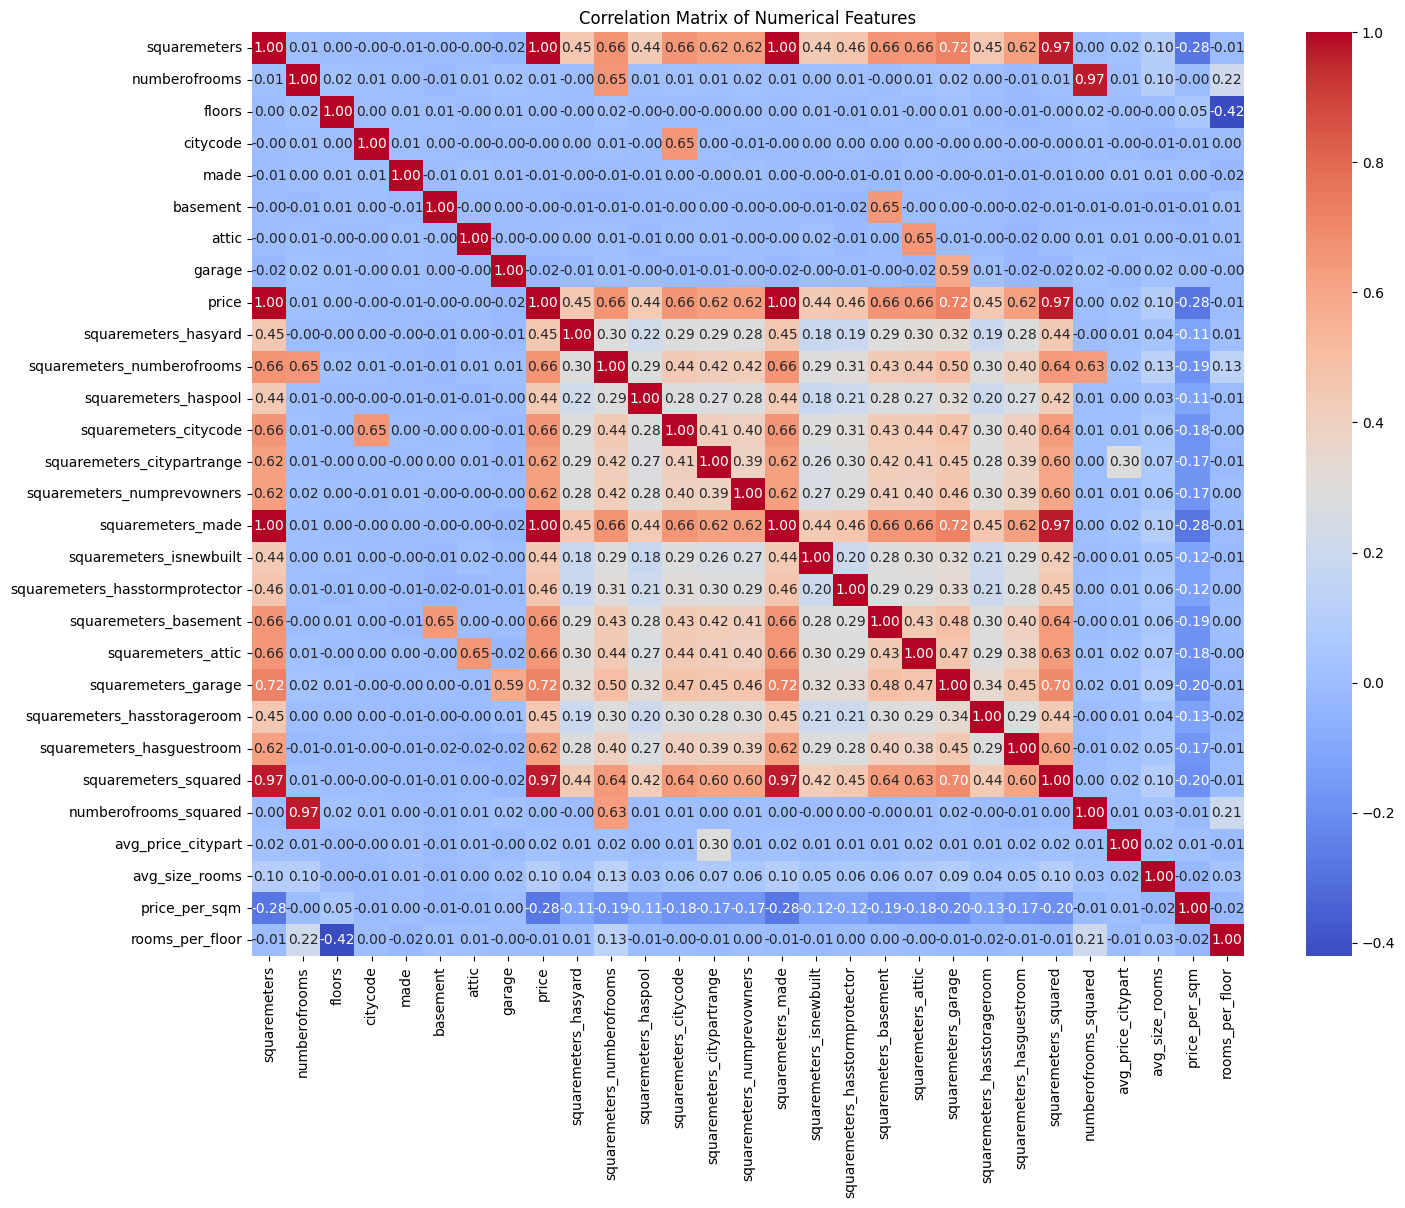

In [501]:
# Assuming df_corr is your correlation matrix
plt.figure(figsize=(16,12))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [502]:
df.dtypes

squaremeters                         int64
numberofrooms                        int64
hasyard                           category
haspool                           category
floors                               int64
citycode                             int64
citypartrange                     category
numprevowners                     category
made                                 int64
isnewbuilt                        category
hasstormprotector                 category
basement                             int64
attic                                int64
garage                               int64
hasstorageroom                    category
hasguestroom                      category
price                              float64
hasyard_num                           int8
squaremeters_hasyard                 int64
squaremeters_numberofrooms           int64
haspool_num                           int8
squaremeters_haspool                 int64
squaremeters_citycode                int64
citypartran

### Mutual Information

In [503]:
from sklearn.feature_selection import mutual_info_regression

# Target column
target = 'price'

# Numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=[target]).columns

# Compute MI
mi_numerical = mutual_info_regression(df[numerical_cols], df[target])
mi_numerical = pd.Series(mi_numerical, index=numerical_cols).sort_values(ascending=False)

print(mi_numerical)

squaremeters                      6.566710
squaremeters_squared              6.445762
squaremeters_made                 4.934643
squaremeters_hasyard              3.298238
squaremeters_hasstorageroom       3.226887
squaremeters_haspool              3.218924
squaremeters_hasstormprotector    3.208021
squaremeters_isnewbuilt           3.203081
squaremeters_numprevowners        3.170956
squaremeters_citypartrange        3.156329
squaremeters_hasguestroom         2.992236
squaremeters_garage               0.750756
price_per_sqm                     0.631042
squaremeters_citycode             0.595984
squaremeters_numberofrooms        0.581909
squaremeters_attic                0.570188
squaremeters_basement             0.570112
citycode                          0.026273
avg_price_citypart                0.011743
attic                             0.005478
floors                            0.005408
numberofrooms_squared             0.004640
numberofrooms                     0.004639
avg_size_ro

/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_50746/2947099977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_numerical.values, y=mi_numerical.index, palette='coolwarm')


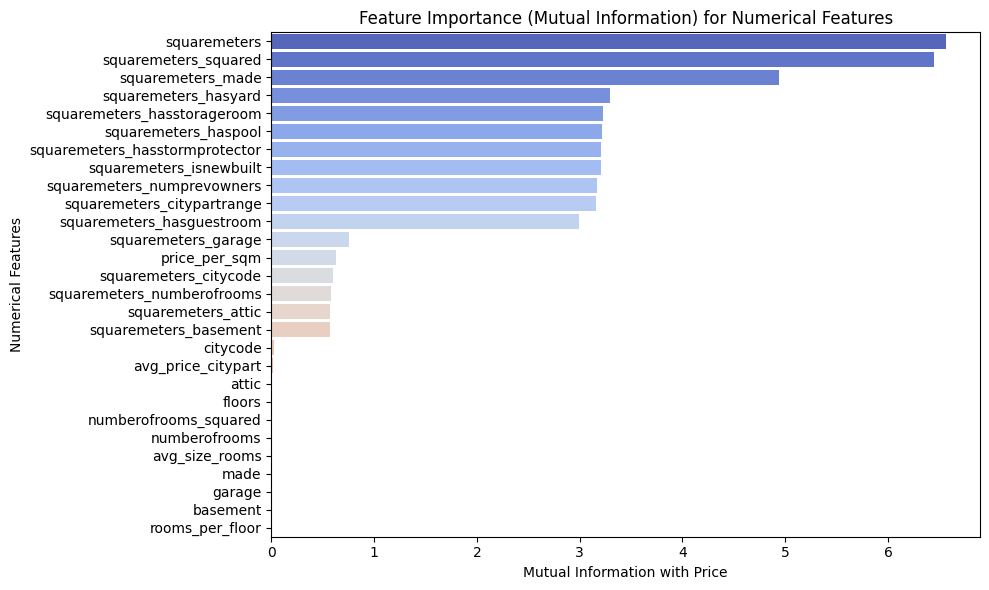

In [507]:
# Plot mutual information for numerical features
plt.figure(figsize=(10,6))
sns.barplot(x=mi_numerical.values, y=mi_numerical.index, palette='coolwarm')
plt.xlabel('Mutual Information with Price')
plt.ylabel('Numerical Features')
plt.title('Feature Importance (Mutual Information) for Numerical Features')
plt.tight_layout()
plt.show()

### Save as CSV

In [508]:
# Save to CSV
df.to_csv('paris_housing_features.csv', index=False)

In [509]:
# Save to pickle
df.to_pickle('paris_housing_features.pkl')